# 03 — Orchestrator + Comparative Analysis

**ZHAW CEC Quantum Computing**

This notebook is the single end-to-end runner for the project:

1. Defines a list of experiments to run
2. Runs each or skips if already cached on disk
3. Loads all `metrics.json` files and produces the comparison figures used in the talk

Notebooks 01 and 02 are useful for **interactive single-run experimentation**. For reproducible end-to-end runs, execute Notebook 03.
Caching makes re-running this notebook is cheap once results exist.

## 0. Setup

In [4]:
import os
if not os.path.isdir('/content/qGAN-market-generator'):
    !git clone https://github.com/wuns/qGAN-market-generator.git
%cd /content/qGAN-market-generator
!pip install -q yfinance 'pennylane>=0.44,<0.45'

Cloning into 'qGAN-market-generator'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 112 (delta 63), reused 39 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 1.80 MiB | 9.69 MiB/s, done.
Resolving deltas: 100% (63/63), done.
/content/qGAN-market-generator
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 38.2 MB/s eta 0:00:00
/content/qGAN-market-generator


In [5]:
import sys, pathlib, json
ROOT = pathlib.Path.cwd()
if (ROOT / 'src').is_dir():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / 'src').is_dir():
    sys.path.insert(0, str(ROOT.parent))
    ROOT = ROOT.parent

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.experiment import ExperimentConfig, run_many

RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Results dir: {RESULTS}')

Device: cpu
Results dir: /content/qGAN-market-generator/results
Device: cpu
Results dir: /content/qGAN-market-generator/results


## 1. Define the experiments to run

Every entry below is a single training run. Edit / extend the list to control what gets executed.

**Caching:** runs whose `results/<folder>/metrics.json` already exist are skipped. To force a re-run, either delete that folder or set `FORCE_RERUN = True` below.

In [6]:
FORCE_RERUN = True     # set True to retrain everything from scratch

# Common settings used everywhere unless overridden
COMMON = dict(seed=42, window=20, epochs=50, batch_size=64)
TICKERS = ['^SSMI', '^GDAXI', '^STOXX50E', '^FTSE', '^GSPC']

# --- The experiment list. Add/remove/edit freely. ---
experiments = [
    # ===== Univariate baselines =====
    ExperimentConfig(family='classical', variant='gan',     tickers=TICKERS,            **COMMON),
    ExperimentConfig(family='quantum',   variant='gan',     tickers=TICKERS,            n_qubits=6, n_layers=3, **COMMON),

    # ===== Multivariate baselines =====
    ExperimentConfig(family='classical', variant='gan',     tickers=TICKERS, **COMMON),
    ExperimentConfig(family='quantum',   variant='gan',     tickers=TICKERS, n_qubits=8, n_layers=3, **COMMON),

    # ===== Qubit-scaling experiment =====
    ExperimentConfig(family='quantum',   variant='gan', tickers=TICKERS, n_qubits=10, n_layers=3, **COMMON),
    ExperimentConfig(family='quantum',   variant='gan', tickers=TICKERS, n_qubits=12, n_layers=3, **COMMON),

    # ===== Matched-size classical baselines (~400 params, comparable to quantum) =====
    # Folder names get the '_h8d6' suffix automatically — distinct from the originals.
    ExperimentConfig(family='classical', variant='gan', tickers=TICKERS, latent_dim=6, hidden=8, **COMMON),
]

print(f'{len(experiments)} experiments configured. Folders that will appear under results/:')
for e in experiments:
    cached = (RESULTS / e.folder_name() / 'metrics.json').is_file()
    flag = '[cached]' if cached and not FORCE_RERUN else '[will run]'
    print(f'  {flag}  {e.folder_name()}')

7 experiments configured. Folders that will appear under results/:
  [will run]  classical_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC
  [will run]  quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q6L3
  [will run]  classical_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC
  [will run]  quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q8L3
  [will run]  quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q10L3
  [will run]  quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q12L3
  [will run]  classical_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_h8d6
7 experiments configured. Folders that will appear under results/:
  [will run]  classical_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC
  [will run]  quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q6L3
  [will run]  classical_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC
  [will run]  quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q8L3
  [will run]  quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q10L3
  [will run]  quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q12L3
  [will run]  classical_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_h8d6


## 2. Run all experiments

Cached runs return immediately; new ones train. Quantum runs are slow (~5-30 min each on Colab CPU); plan accordingly. Total expected runtime, fresh, ranges from 30 minutes (univariate only) to 2-3 hours (full list above).

In [7]:
all_metrics = run_many(experiments, results_root=RESULTS, force_rerun=FORCE_RERUN, device=device)
print(f'\nDone. {len(all_metrics)} metrics dicts available in `all_metrics`.')

[running]     classical_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC
  variant=vanilla GAN  assets=['^SSMI', '^GDAXI', '^STOXX50E', '^FTSE', '^GSPC']  G params=4644  A params=8577
  epoch  12/50  D=1.077  G=0.964
  epoch  24/50  D=0.746  G=1.398
  epoch  36/50  D=0.756  G=1.447
  epoch  48/50  D=0.869  G=1.454
  saved -> /content/qGAN-market-generator/results/classical_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC

[running]     quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q6L3
  variant=vanilla GAN  assets=['^SSMI', '^GDAXI', '^STOXX50E', '^FTSE', '^GSPC']  G params=718  A params=8577
  epoch  12/50  D=0.674  G=1.714
  epoch  24/50  D=0.143  G=3.137
  epoch  36/50  D=0.073  G=3.741
  epoch  48/50  D=0.066  G=3.793
  saved -> /content/qGAN-market-generator/results/quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q6L3

[running]     classical_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC
  variant=vanilla GAN  assets=['^SSMI', '^GDAXI', '^STOXX50E', '^FTSE', '^GSPC']  G params=4644  A params=8577
  epoch  12/50  D=1.077  G=0.964
 

## 3. Load all results into a tidy table

We re-read from disk rather than using `all_metrics` directly, so this works even on a fresh notebook session that just discovers existing folders without running anything.

In [8]:
def parse_run_folder(folder_name: str) -> dict:
    parts = folder_name.split('_')
    family  = parts[0]
    variant = 'wgan_gp' if 'wgan' in folder_name else 'gan'
    suffix  = folder_name
    for prefix in [f'{family}_{variant}_', f'{family}_']:
        if suffix.startswith(prefix):
            suffix = suffix[len(prefix):]
            break
    qubits = layers = None
    asset_part = suffix
    if '_q' in suffix and 'L' in suffix.split('_q')[-1]:
        asset_part, q_suffix = suffix.rsplit('_q', 1)
        try:
            qubits, layers = q_suffix.split('L')
            qubits, layers = int(qubits), int(layers)
        except ValueError:
            pass
    return {'family': family, 'variant': variant, 'assets': asset_part,
            'n_qubits': qubits, 'n_layers': layers}

rows = []
for folder in sorted(RESULTS.iterdir()):
    if not folder.is_dir(): continue
    metrics_file = folder / 'metrics.json'
    if not metrics_file.is_file(): continue
    with open(metrics_file) as f:
        m = json.load(f)
    parsed = parse_run_folder(folder.name)
    row = {'run': folder.name, **parsed,
           'ks':                m.get('ks_statistic_overall'),
           'training_time_sec': m.get('training_time_sec'),
           'n_params_G':        m.get('n_params_generator'),
           'n_params_D':        m.get('n_params_discriminator')}
    if 'dependence' in m:
        row['bures_wasserstein']   = m['dependence'].get('bures_wasserstein')
        row['frobenius_cov']       = m['dependence'].get('frobenius_cov_err')
        row['frobenius_corr']      = m['dependence'].get('frobenius_corr_err')
    elif 'correlation' in m:
        row['frobenius_corr']      = m['correlation'].get('frobenius_err')
    if 'real_per_asset' in m:
        kr = np.mean([v['kurtosis'] for v in m['real_per_asset'].values()])
        kf = np.mean([v['kurtosis'] for v in m['fake_per_asset'].values()])
        sr = np.mean([v['std']      for v in m['real_per_asset'].values()])
        sf = np.mean([v['std']      for v in m['fake_per_asset'].values()])
        row.update({'kurtosis_real': kr, 'kurtosis_fake': kf,
                    'kurtosis_gap':  abs(kr - kf),
                    'std_real': sr, 'std_fake': sf,
                    'std_rel_err': abs(sr - sf) / max(sr, 1e-12)})
    rows.append(row)

df = pd.DataFrame(rows)
if df.empty:
    print('No results found in', RESULTS)
else:
    print(f'Loaded {len(df)} runs:')
    print(df[['family', 'variant', 'assets', 'n_qubits', 'n_layers', 'ks',
              'training_time_sec']].to_string(index=False))

Loaded 6 runs:
   family variant                             assets  n_qubits  n_layers      ks  training_time_sec
classical     gan      SSMI_GDAXI_STOXX50E_FTSE_GSPC       NaN       NaN 0.15465              11.59
classical     gan SSMI_GDAXI_STOXX50E_FTSE_GSPC_h8d6       NaN       NaN 0.07096              15.78
  quantum     gan      SSMI_GDAXI_STOXX50E_FTSE_GSPC      10.0       3.0 0.06267             731.62
  quantum     gan      SSMI_GDAXI_STOXX50E_FTSE_GSPC      12.0       3.0 0.08517            2573.21
  quantum     gan      SSMI_GDAXI_STOXX50E_FTSE_GSPC       6.0       3.0 0.10404             179.92
  quantum     gan      SSMI_GDAXI_STOXX50E_FTSE_GSPC       8.0       3.0 0.07999             316.27


## 4. Summary table

In [9]:
summary = pd.DataFrame()
if not df.empty:
    cols = ['family', 'variant', 'assets', 'n_qubits', 'n_layers',
            'n_params_G', 'training_time_sec',
            'ks', 'std_rel_err', 'kurtosis_gap']
    if 'bures_wasserstein' in df.columns: cols.append('bures_wasserstein')
    if 'frobenius_corr'   in df.columns: cols.append('frobenius_corr')
    summary = df[[c for c in cols if c in df.columns]].copy()
    summary = summary.sort_values(['assets', 'family', 'variant', 'n_qubits'])
    summary.to_csv(RESULTS / 'summary.csv', index=False)
    print('Saved -> results/summary.csv')
summary

Saved -> results/summary.csv


,family,variant,assets,n_qubits,n_layers,n_params_G,training_time_sec,ks,std_rel_err,kurtosis_gap,frobenius_corr
0,classical,gan,SSMI_GDAXI_STOXX50E_FTSE_GSPC,NaN,NaN,4644,11.59,0.15465,0.515308,3.329820,1.786367
4,quantum,gan,SSMI_GDAXI_STOXX50E_FTSE_GSPC,6.0,3.0,718,179.92,0.10404,0.434212,2.663637,1.215358
5,quantum,gan,SSMI_GDAXI_STOXX50E_FTSE_GSPC,8.0,3.0,924,316.27,0.07999,0.291538,2.518268,0.714471
2,quantum,gan,SSMI_GDAXI_STOXX50E_FTSE_GSPC,10.0,3.0,1130,731.62,0.06267,0.246409,1.682414,0.502068
3,quantum,gan,SSMI_GDAXI_STOXX50E_FTSE_GSPC,12.0,3.0,1336,2573.21,0.08517,0.270640,1.667143,0.339438
1,classical,gan,SSMI_GDAXI_STOXX50E_FTSE_GSPC_h8d6,NaN,NaN,1028,15.78,0.07096,0.324385,1.692568,1.664668


## 5. Headline comparison: classical vs quantum (paired)

In [10]:
paired_keys = []
if not df.empty:
    for (variant, assets), sub in df.groupby(['variant', 'assets']):
        if {'classical', 'quantum'}.issubset(set(sub['family'])):
            paired_keys.append((variant, assets))
print(f'Paired (variant, assets) groups: {paired_keys}')

Paired (variant, assets) groups: [('gan', 'SSMI_GDAXI_STOXX50E_FTSE_GSPC')]


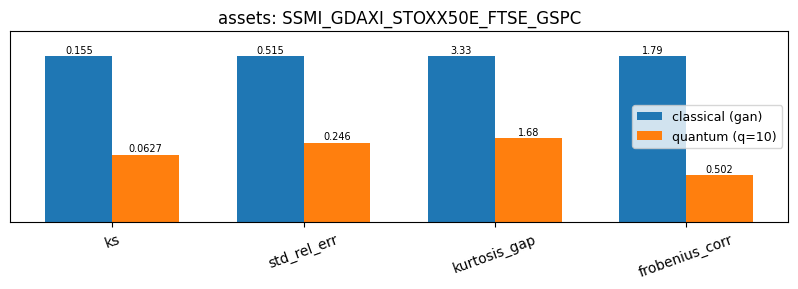

Saved -> results/comparison_classical_vs_quantum.png


In [25]:
if paired_keys:
    metric_cols = [c for c in ['ks', 'std_rel_err', 'kurtosis_gap',
                                'bures_wasserstein', 'frobenius_corr']
                   if c in df.columns]
    fig, axes = plt.subplots(len(paired_keys), 1,
                              figsize=(2 + 1.6 * len(metric_cols), 3 * len(paired_keys)),
                              squeeze=False)

    for ax, (variant, assets) in zip(axes[:, 0], paired_keys):
        sub = df[(df['variant'] == variant) & (df['assets'] == assets)]
        cls = sub[sub['family'] == 'classical'].iloc[0]
        qnt = sub[sub['family'] == 'quantum'].sort_values(
            'n_qubits', na_position='first').iloc[-2]
        cls_v = np.array([cls.get(c) for c in metric_cols], dtype=float)
        qnt_v = np.array([qnt.get(c) for c in metric_cols], dtype=float)
        denom = np.where(np.maximum(cls_v, qnt_v) == 0, 1.0,
                          np.maximum(cls_v, qnt_v))
        x, w = np.arange(len(metric_cols)), 0.35
        ax.bar(x - w/2, cls_v / denom, w, label=f'classical ({variant})')
        ax.bar(x + w/2, qnt_v / denom, w,
                label=f"quantum (q={int(qnt['n_qubits'])})" if pd.notna(qnt['n_qubits']) else 'quantum')
        ax.set_xticks(x); ax.set_xticklabels(metric_cols, rotation=20)
        # ax.set_ylabel('normalized\n(0=better)')
        ax.set_title(f'assets: {assets}')#  |  variant: {variant}')
        ax.legend(loc='right', fontsize=9)
        ax.set_ylim(0, 1.15)
        for i, v in enumerate(cls_v):
            ax.text(i - w/2, cls_v[i]/denom[i] + 0.02, f'{v:.3g}',
                     ha='center', fontsize=7)
        for i, v in enumerate(qnt_v):
            ax.text(i + w/2, qnt_v[i]/denom[i] + 0.02, f'{v:.3g}',
                     ha='center', fontsize=7)
    plt.tight_layout()
    plt.yticks([])
    plt.savefig(RESULTS / 'comparison_classical_vs_quantum.png', dpi=140, bbox_inches='tight')
    plt.show()
    print('Saved -> results/comparison_classical_vs_quantum.png')
else:
    print('No (variant, assets) pair has both classical and quantum results yet.')

## 6. Distribution overlay (one chosen comparison)

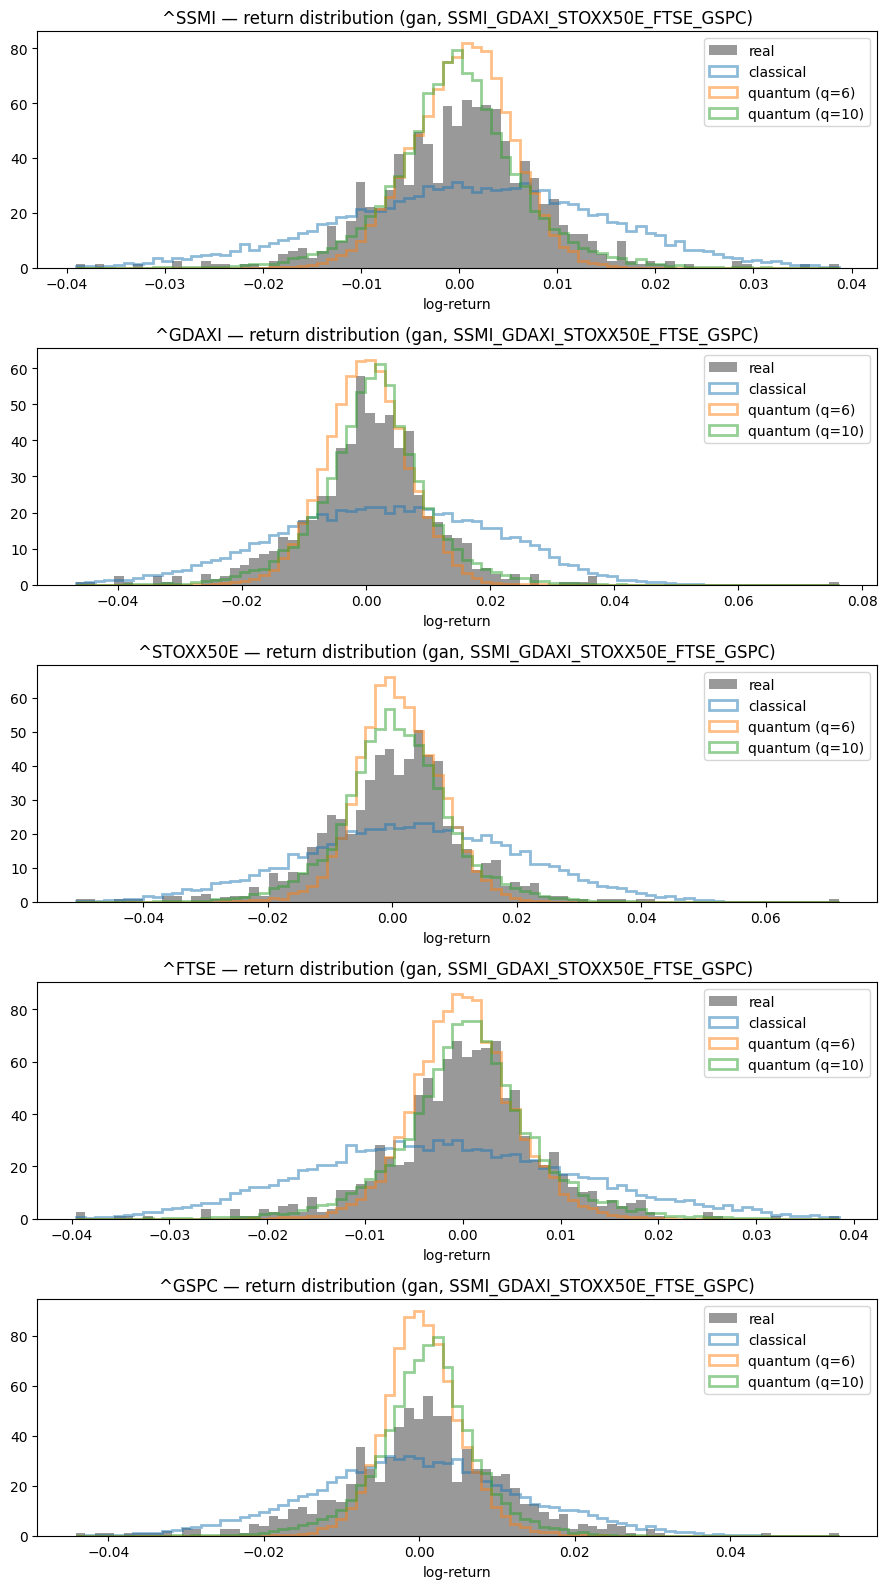

In [33]:
PICK_VARIANT = 'gan'
PICK_ASSETS  = 'SSMI_GDAXI_STOXX50E_FTSE_GSPC'

sub = pd.DataFrame()
n_assets = 0
tickers = []
first_metrics = {}
if not df.empty:
    sub = df[(df['variant'] == PICK_VARIANT) & (df['assets'] == PICK_ASSETS)]
    sub = sub.sort_values('n_qubits', na_position='first')
    sub = sub[~sub['n_qubits'].isin([8, 12])]
    if sub.empty:
        print(f'No runs for {PICK_VARIANT} / {PICK_ASSETS}. Available: '
              f'{df[["variant","assets"]].drop_duplicates().to_dict("records")}')
    else:
        first = sub.iloc[0]
        first_metrics = json.load(open(RESULTS / first['run'] / 'metrics.json'))
        tickers  = first_metrics['tickers']
        n_assets = len(tickers)

        real = np.load(RESULTS / first['run'] / 'real_returns_test.npy')
        if real.ndim == 2: real = real[..., None]

        fig, axes = plt.subplots(n_assets, 1, figsize=(9, 3.2 * n_assets), squeeze=False)
        for i, ticker in enumerate(tickers):
            ax = axes[i, 0]
            real_flat = real[:, :, i].ravel()
            bins = np.linspace(real_flat.min(), real_flat.max(), 80)
            ax.hist(real_flat, bins=bins, alpha=0.4, density=True, label='real',
                     color='black', histtype='stepfilled')
            for _, row in sub.iterrows():
                fake = np.load(RESULTS / row['run'] / 'fake_returns.npy')
                if fake.ndim == 2: fake = fake[..., None]
                fake_flat = fake[:, :, i].ravel()
                tag = row['family'] + (f" (q={int(row['n_qubits'])})"
                                        if pd.notna(row['n_qubits']) else '')
                ax.hist(fake_flat, bins=bins, alpha=0.5, density=True,
                         label=tag, histtype='step', linewidth=2)
            ax.set_title(f'{ticker} — return distribution ({PICK_VARIANT}, {PICK_ASSETS})')
            ax.set_xlabel('log-return'); ax.legend()
        plt.tight_layout()
        plt.savefig(RESULTS / f'distributions_{PICK_VARIANT}_{PICK_ASSETS}.png',
                    dpi=140, bbox_inches='tight')
        plt.show()

## 7. Cross-asset correlation comparison (multivariate only)

In [53]:
sub_check = df[(df['variant'] == 'gan') & (df['assets'] == 'SSMI_GDAXI_STOXX50E_FTSE_GSPC')]
print(sub_check[['run', 'family', 'n_qubits']])

                                               run     family  n_qubits
0      classical_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC  classical       NaN
2  quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q10L3    quantum      10.0
3  quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q12L3    quantum      12.0
4   quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q6L3    quantum       6.0
5   quantum_gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC_q8L3    quantum       8.0


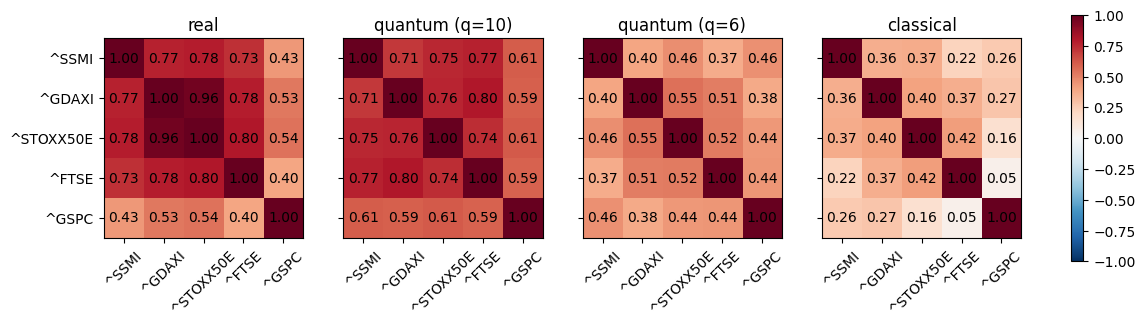

In [54]:
sub = df[(df['variant'] == PICK_VARIANT) & (df['assets'] == PICK_ASSETS)]
sub = sub[
    (sub['family'] == 'classical')
    | sub['n_qubits'].isin([6, 10])
]
sub = sub.sort_values('n_qubits', ascending=False, na_position='last')


if not sub.empty and n_assets >= 2:
    sub = sub[(sub['family'] == 'classical') | sub['n_qubits'].isin([6, 10])]
    sub = sub.sort_values('n_qubits', ascending=False, na_position='last')
    n_runs = len(sub)
    fig, axes = plt.subplots(1, n_runs + 1, figsize=(3.2 * (n_runs + 1), 3.2))
    real_corr = np.array(first_metrics.get('dependence', first_metrics.get('correlation', {}))
                          ['real_corr'])
    im = axes[0].imshow(real_corr, vmin=-1, vmax=1, cmap='RdBu_r')
    axes[0].set_title('real')
    axes[0].set_xticks(range(n_assets)); axes[0].set_yticks(range(n_assets))
    axes[0].set_xticklabels(tickers, rotation=45); axes[0].set_yticklabels(tickers)
    for i in range(n_assets):
        for j in range(n_assets):
            axes[0].text(j, i, f'{real_corr[i,j]:.2f}', ha='center', va='center')

    for k, (_, row) in enumerate(sub.iterrows()):
        m = json.load(open(RESULTS / row['run'] / 'metrics.json'))
        dep = m.get('dependence', m.get('correlation', {}))
        fake_corr = np.array(dep['fake_corr'])
        ax = axes[k + 1]
        ax.imshow(fake_corr, vmin=-1, vmax=1, cmap='RdBu_r')
        tag = row['family'] + (f" (q={int(row['n_qubits'])})"
                                if pd.notna(row['n_qubits']) else '')
        ax.set_title(tag)
        ax.set_xticks(range(n_assets)); ax.set_yticks(range(n_assets))
        ax.set_xticklabels(tickers, rotation=45); ax.set_yticklabels([])
        for i in range(n_assets):
            for j in range(n_assets):
                ax.text(j, i, f'{fake_corr[i,j]:.2f}', ha='center', va='center')
    fig.colorbar(im, ax=axes, fraction=0.025)
    plt.savefig(RESULTS / f'correlation_{PICK_VARIANT}_{PICK_ASSETS}.png',
                dpi=140, bbox_inches='tight')
    plt.show()
elif n_assets < 2:
    print(f'Only {n_assets} asset(s) — correlation plot skipped.')

## 8. Qubit-scaling plot

Uses any quantum runs at multiple qubit counts (same variant + assets) that exist in `results/`.

In [14]:
scan_df = pd.DataFrame()
if not df.empty:
    scan_data = []
    for (variant, assets), grp in df[df['family'] == 'quantum'].groupby(['variant', 'assets']):
        grp = grp.sort_values('n_qubits')
        if grp['n_qubits'].nunique() >= 2:
            for _, r in grp.iterrows():
                scan_data.append({
                    'source': f'{variant}_{assets}',
                    'n_qubits': r['n_qubits'], 'ks': r['ks'],
                    'training_time_sec': r['training_time_sec'],
                    'kurtosis_fake': r.get('kurtosis_fake'),
                    'kurtosis_real': r.get('kurtosis_real'),
                })
    scan_df = pd.DataFrame(scan_data)
if scan_df.empty:
    print('No qubit-scaling data yet. Add quantum experiments at multiple n_qubits.')
else:
    print(scan_df.to_string(index=False))

                           source  n_qubits      ks  training_time_sec  kurtosis_fake  kurtosis_real
gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC       6.0 0.10404             179.92       0.458242       3.121879
gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC       8.0 0.07999             316.27       0.603611       3.121879
gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC      10.0 0.06267             731.62       1.439465       3.121879
gan_SSMI_GDAXI_STOXX50E_FTSE_GSPC      12.0 0.08517            2573.21       1.454736       3.121879


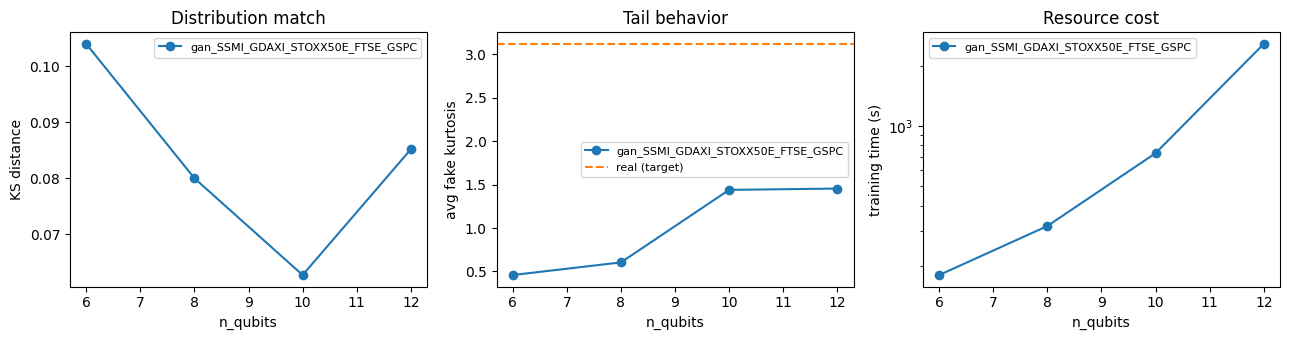

Saved -> results/qubit_scaling.png


In [15]:
if not scan_df.empty:
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
    for src, grp in scan_df.groupby('source'):
        grp = grp.sort_values('n_qubits')
        ax[0].plot(grp['n_qubits'], grp['ks'], 'o-', label=src)
        ax[1].plot(grp['n_qubits'], grp['kurtosis_fake'], 'o-', label=src)
        ax[2].plot(grp['n_qubits'], grp['training_time_sec'], 'o-', label=src)
    if scan_df['kurtosis_real'].notna().any():
        ax[1].axhline(scan_df['kurtosis_real'].dropna().iloc[0],
                       color='C1', ls='--', label='real (target)')
    ax[0].set_xlabel('n_qubits'); ax[0].set_ylabel('KS distance')
    ax[0].set_title('Distribution match'); ax[0].legend(fontsize=8)
    ax[1].set_xlabel('n_qubits'); ax[1].set_ylabel('avg fake kurtosis')
    ax[1].set_title('Tail behavior'); ax[1].legend(fontsize=8)
    ax[2].set_xlabel('n_qubits'); ax[2].set_ylabel('training time (s)')
    ax[2].set_yscale('log'); ax[2].set_title('Resource cost'); ax[2].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(RESULTS / 'qubit_scaling.png', dpi=140, bbox_inches='tight')
    plt.show()
    print('Saved -> results/qubit_scaling.png')

## 9. Auto-generated talking points

In [16]:
for (variant, assets) in paired_keys:
    s = df[(df['variant'] == variant) & (df['assets'] == assets)]
    cls = s[s['family'] == 'classical'].iloc[0]
    qnt = s[s['family'] == 'quantum'].sort_values('n_qubits',
                                                    na_position='first').iloc[-1]
    print(f'\n--- assets={assets} | variant={variant} ---')
    print(f'  Generator params:    classical={cls["n_params_G"]}, quantum={qnt["n_params_G"]}')
    if pd.notna(qnt['n_qubits']):
        qq = int(qnt['n_qubits']) * int(qnt['n_layers'])
        print(f"    (quantum: {int(qnt['n_qubits'])}q x {int(qnt['n_layers'])}L = {qq} quantum params)")
    print(f'  Training time:       classical={cls["training_time_sec"]:.1f}s,  '
          f'quantum={qnt["training_time_sec"]:.1f}s  '
          f'(quantum {qnt["training_time_sec"]/max(cls["training_time_sec"],0.1):.1f}x slower)')
    print(f'  KS distance:         classical={cls["ks"]:.4f},  quantum={qnt["ks"]:.4f}')
    if pd.notna(cls.get('bures_wasserstein')):
        print(f'  Bures-Wasserstein:   classical={cls["bures_wasserstein"]:.6f},  '
              f'quantum={qnt["bures_wasserstein"]:.6f}')
    print(f'  Std rel. error:      classical={cls["std_rel_err"]:.3f},  '
          f'quantum={qnt["std_rel_err"]:.3f}')
    print(f'  Kurtosis gap:        classical={cls["kurtosis_gap"]:.2f},  '
          f'quantum={qnt["kurtosis_gap"]:.2f}  (real={cls["kurtosis_real"]:.2f})')


--- assets=SSMI_GDAXI_STOXX50E_FTSE_GSPC | variant=gan ---
  Generator params:    classical=4644, quantum=1336
    (quantum: 12q x 3L = 36 quantum params)
  Training time:       classical=11.6s,  quantum=2573.2s  (quantum 222.0x slower)
  KS distance:         classical=0.1547,  quantum=0.0852
  Std rel. error:      classical=0.515,  quantum=0.271
  Kurtosis gap:        classical=3.33,  quantum=1.67  (real=3.12)


## What's been saved

Outputs in `results/`:
- `summary.csv`
- `comparison_classical_vs_quantum.png`
- `distributions_<variant>_<assets>.png`
- `correlation_<variant>_<assets>.png`
- `qubit_scaling.png`

All trained models persist in `results/<folder>/generator.pt` for later use.